## Imports

In [27]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import numpy as np
from math import ceil

## Load Data

In [28]:
'''Load base vectors.'''
base = []
with open("../tmp/base_sorted.txt", 'r') as f:
    for line in f:
        line = line.strip().split(' ')
        base.append([float(i) for i in line])
base = np.array(base)

'''Load groupings.'''
grouping = []
with open("../tmp/grouping.txt", 'r') as f:
    line = f.readline().strip().split(' ')
    for i in line:
        grouping.append(int(i))

'''Load graph.'''
graph = []
with open("../tmp/graph.txt", 'r') as f:
    for line in f:
        line = line.strip().split(' ')
        graph.append((int(line[0]), int(line[1])))

base, grouping

(array([[ 2.90047  , -0.498674 ,  1.85539  ],
        [ 2.56648  ,  1.81673  , -0.878216 ],
        [ 0.254487 , -3.64913  , -0.229954 ],
        ...,
        [-0.0461392, -0.144618 , -0.0806019],
        [ 0.119879 , -0.0910841, -0.12605  ],
        [ 0.122933 , -0.149152 , -0.0683459]]),
 [0,
  22,
  55,
  84,
  117,
  155,
  188,
  226,
  269,
  309,
  352,
  406,
  443,
  487,
  527,
  570,
  614,
  659,
  701,
  741,
  771,
  805,
  843,
  877,
  906,
  933,
  955,
  973,
  989,
  998,
  1000])

## Plot Graph

C:\Users\xiach\AppData\Local\Temp\ipykernel_87076\3135284268.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x, y, z, c=colors[i], alpha=0.8)
C:\Users\xiach\AppData\Local\Temp\ipykernel_87076\3135284268.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


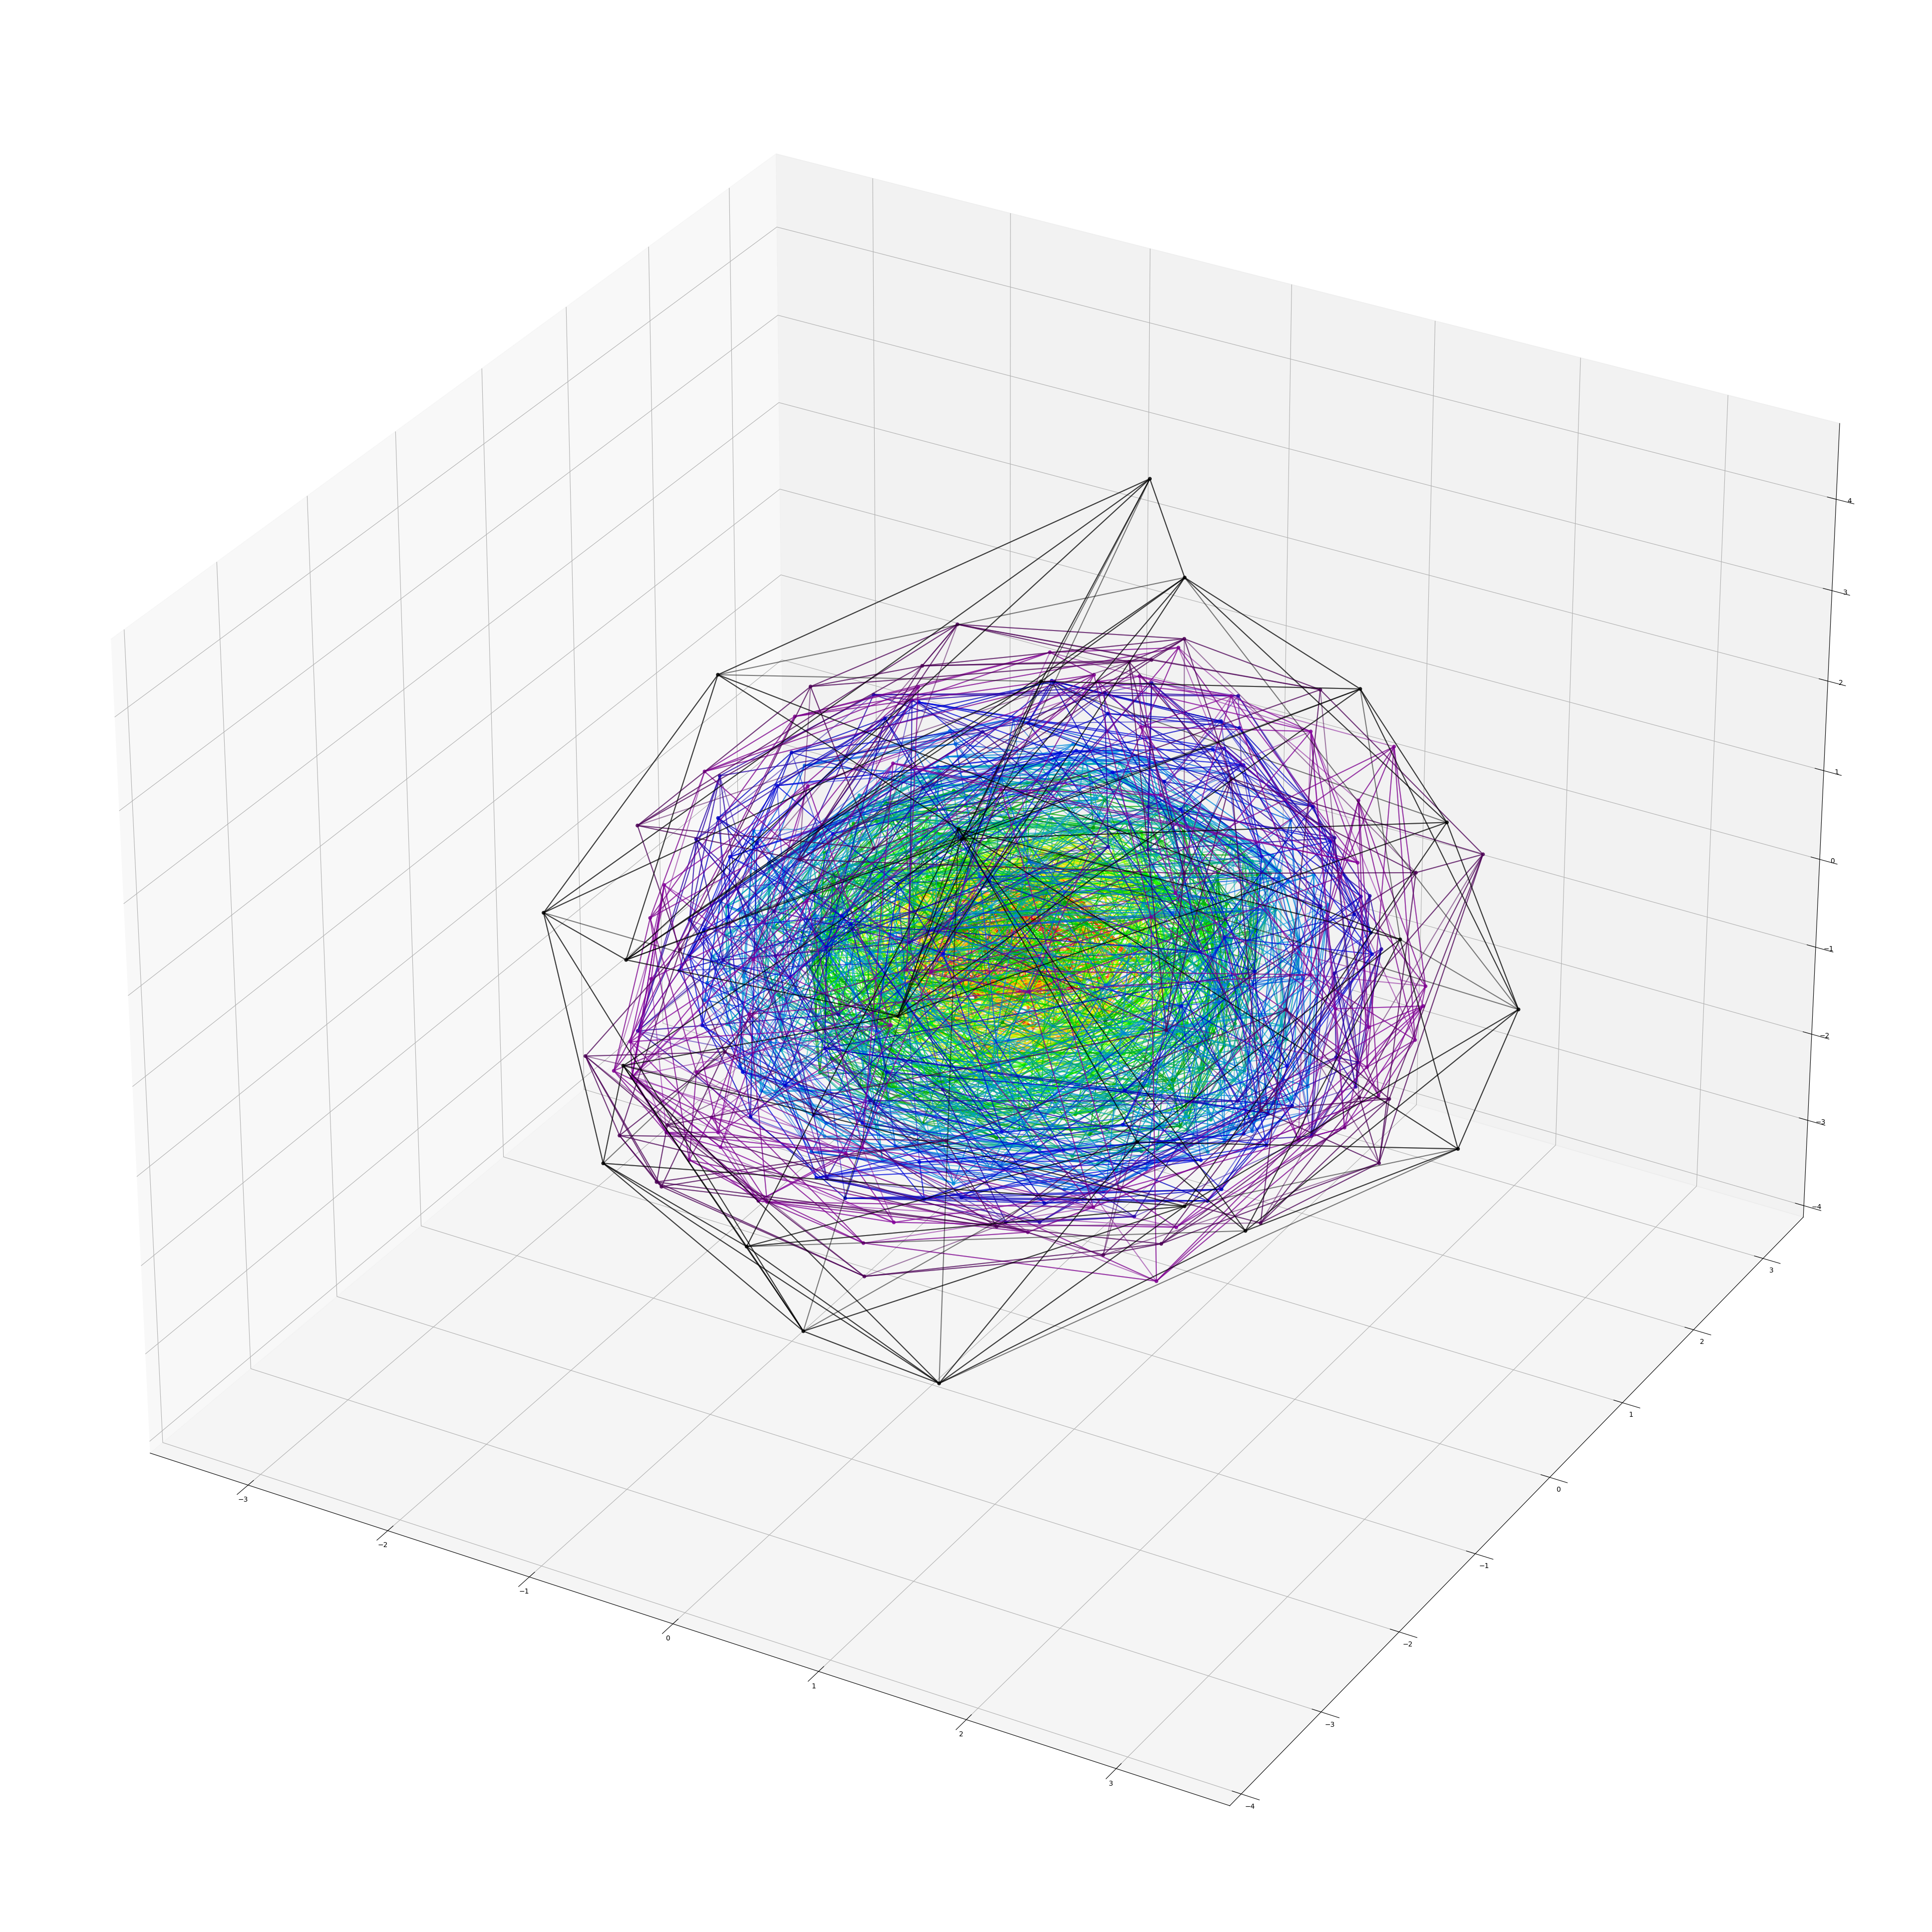

In [29]:
'''Full Figure'''
fig, ax = plt.subplots(figsize=(50, 50), subplot_kw={"projection": "3d"})

colors = colormaps["nipy_spectral"](np.linspace(0, 1, len(grouping) - 1))
for i in range(len(grouping) - 1):
    l = grouping[i]
    r = grouping[i+1]
    x = base[l:r, 0]
    y = base[l:r, 1]
    z = base[l:r, 2]
    segments = []
    for (j, k) in graph:
        if l <= j < r and l <= k < r:
            segments.append([base[j], base[k]])
    lc = Line3DCollection(segments, colors=colors[i], alpha=0.5)
    ax.add_collection(lc)
    ax.scatter(x, y, z, c=colors[i], alpha=0.8)

fig.show()